In [1]:
!pwd  # 현재 작업하고 있는 폴더 (working directory)

/home/moon9342/jupyter_home


In [2]:
import os   # 폴더 경로 생성하기 위해
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator # 입력데이터 처리
from tensorflow.keras.applications import VGG16   # 성능은 좋지 않지만 알기쉬운 
                                                  # pretrained network(기학습된 네트워크)
from tensorflow.keras.models import Sequential # Model
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.layers import BatchNormalization, Activation
from tensorflow.keras.optimizers import SGD, RMSprop, Adam
import warnings
warnings.filterwarnings('ignore')

train_dir = './data/cat_dog_small/train'  # 학습용 이미지가 들어가 있는 폴더(상대경로)
validation_dir = './data/cat_dog_small/validation'

# ImageDataGenerator를 생성. 당연히 2개 생성
# train용 1개 - 증식설정이 들어가야 해요!, validation용 1개 - 증식이 들어가면 안되요!
train_datagen = ImageDataGenerator(rescale=1/255.0,
                                   rotation_range=30,
                                   width_shift_range=0.1,
                                   height_shift_range=0.1,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True,
                                   vertical_flip=False,
                                   fill_mode='nearest')

# validation data는 증식을 시키면 안되요!
validation_datagen = ImageDataGenerator(rescale=1/255.0)

# ImageDataGenerator 설정
train_generator = train_datagen.flow_from_directory(
    train_dir,
    classes=['cats', 'dogs'], 
    target_size=(150,150),
    batch_size=20,
    class_mode='binary'
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    classes=['cats', 'dogs'], 
    target_size=(150,150),
    batch_size=20,
    class_mode='binary'
)

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [4]:
# Model 구현

model_base = VGG16(weights='imagenet',
                   include_top=False,
                   input_shape=(150,150,3))

model_base.trainable = False # VGG16안의 convolution layer를 동결(중요!)

model = Sequential()

model.add(model_base)  # 특징추출하는 부분(이미지 1장이 3차원)

model.add(Flatten())   # classifier로 넣어야 해요!(이미지 1장을 1차원)
# hidden layer
model.add(Dense(units=128))
model.add(BatchNormalization())  # 성능향상을 위해 BatchNormalization을 사용해요!
model.add(Activation('relu'))

model.add(Dropout(rate=0.2)) # Activation뒤에 위치시키는게 좋아요!(Dense뒤에 위치)
                     # Convolution layer에서는 Dropout을 일반적으로 사용하지 않아요!
# output layer
model.add(Dense(units=1,
                activation='sigmoid'))

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 4, 4, 512)         14714688  
                                                                 
 flatten_1 (Flatten)         (None, 8192)              0         
                                                                 
 dense_2 (Dense)             (None, 128)               1048704   
                                                                 
 batch_normalization_1 (Bat  (None, 128)               512       
 chNormalization)                                                
                                                                 
 activation_1 (Activation)   (None, 128)               0         
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                      

In [5]:
# Model 설정
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [6]:
# Model 학습
history = model.fit(train_generator,
                    steps_per_epoch=100,
                    epochs=30,
                    validation_data=validation_generator,
                    validation_steps=50,
                    verbose=1)

Epoch 1/30
100/100 [==============================] - 11s 93ms/step - loss: 0.4951 - accuracy: 0.7410 - val_loss: 0.4357 - val_accuracy: 0.7810
Epoch 2/30
100/100 [==============================] - 9s 86ms/step - loss: 0.3611 - accuracy: 0.8450 - val_loss: 0.2898 - val_accuracy: 0.8790
Epoch 3/30
100/100 [==============================] - 9s 88ms/step - loss: 0.3201 - accuracy: 0.8535 - val_loss: 0.2603 - val_accuracy: 0.8830
Epoch 4/30
100/100 [==============================] - 9s 90ms/step - loss: 0.3001 - accuracy: 0.8730 - val_loss: 0.2471 - val_accuracy: 0.8980
Epoch 5/30
100/100 [==============================] - 9s 91ms/step - loss: 0.2880 - accuracy: 0.8770 - val_loss: 0.2383 - val_accuracy: 0.9040
Epoch 6/30
100/100 [==============================] - 9s 92ms/step - loss: 0.2805 - accuracy: 0.8835 - val_loss: 0.2405 - val_accuracy: 0.8940
Epoch 7/30
100/100 [==============================] - 9s 90ms/step - loss: 0.2588 - accuracy: 0.8880 - val_loss: 0.2577 - val_accuracy: 0.891

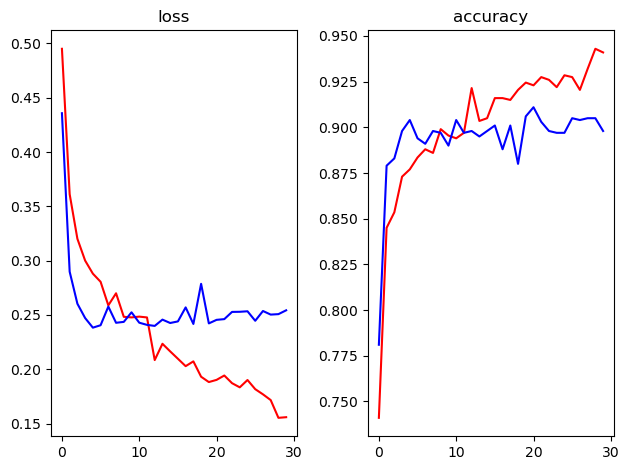

In [8]:
# 그래프
fig = plt.figure()

ax1 = fig.add_subplot(1,2,1)
ax2 = fig.add_subplot(1,2,2)

ax1.set_title('loss')
ax1.plot(history.history['loss'], color='r')
ax1.plot(history.history['val_loss'], color='b')

ax2.set_title('accuracy')
ax2.plot(history.history['accuracy'], color='r')
ax2.plot(history.history['val_accuracy'], color='b')

fig.tight_layout()
plt.show()



In [16]:
%reset
# 고양이와 멍멍이 이진분류 문제를
# VGG16을 이용한 Fine tuning으로 모델을 구현해 보아요!

# 데이터처리
import os   # 폴더 경로 생성하기 위해
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator # 입력데이터 처리
from tensorflow.keras.applications import VGG16   # 성능은 좋지 않지만 알기쉬운 
                                                  # pretrained network(기학습된 네트워크)
from tensorflow.keras.models import Sequential # Model
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.layers import BatchNormalization, Activation
from tensorflow.keras.optimizers import SGD, RMSprop, Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import warnings
warnings.filterwarnings('ignore')

train_dir = './data/cat_dog_small/train'  # 학습용 이미지가 들어가 있는 폴더(상대경로)
validation_dir = './data/cat_dog_small/validation'

# ImageDataGenerator를 생성. 당연히 2개 생성
# train용 1개 - 증식설정이 들어가야 해요!, validation용 1개 - 증식이 들어가면 안되요!
train_datagen = ImageDataGenerator(rescale=1/255.0,
                                   rotation_range=30,
                                   width_shift_range=0.1,
                                   height_shift_range=0.1,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True,
                                   vertical_flip=False,
                                   fill_mode='nearest')

# validation data는 증식을 시키면 안되요!
validation_datagen = ImageDataGenerator(rescale=1/255.0)

# ImageDataGenerator 설정
train_generator = train_datagen.flow_from_directory(
    train_dir,
    classes=['cats', 'dogs'], 
    target_size=(150,150),
    batch_size=20,
    class_mode='binary'
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    classes=['cats', 'dogs'], 
    target_size=(150,150),
    batch_size=20,
    class_mode='binary'
)

# Model 구현
model_base = VGG16(weights='imagenet',
                   include_top=False,
                   input_shape=(150,150,3))

model_base.trainable = False # VGG16안의 convolution layer를 동결(중요!)

model = Sequential()

model.add(model_base)  # 특징추출하는 부분(이미지 1장이 3차원)

model.add(Flatten())   # classifier로 넣어야 해요!(이미지 1장을 1차원)
# hidden layer
model.add(Dense(units=128))
model.add(BatchNormalization())  # 성능향상을 위해 BatchNormalization을 사용해요!
model.add(Activation('relu'))

model.add(Dropout(rate=0.2)) # Activation뒤에 위치시키는게 좋아요!(Dense뒤에 위치)
                     # Convolution layer에서는 Dropout을 일반적으로 사용하지 않아요!
# output layer
model.add(Dense(units=1,
                activation='sigmoid'))

# Model 설정
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# EarlyStopping callback이 필요
es_callback = EarlyStopping(monitor='val_loss',
                            patience=5,
                            restore_best_weights=True,
                            verbose=1)

cp_callback = ModelCheckpoint(filepath='./finetune.weights.h5',
                              save_best_only=True,
                              save_weights_only=True,
                              monitor='val_accuracy',
                              verbose=1) 

# Model 학습
model.fit(train_generator,
          steps_per_epoch=100,
          epochs=30,
          validation_data=validation_generator,
          validation_steps=50,
          callbacks=[es_callback, cp_callback],
          verbose=1)

Once deleted, variables cannot be recovered. Proceed (y/[n])?  y


Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Epoch 1/30
100/100 [==============================] - ETA: 0s - loss: 0.5321 - accuracy: 0.7365  
Epoch 1: val_accuracy improved from -inf to 0.85900, saving model to ./finetune.weights.h5
100/100 [==============================] - 11s 96ms/step - loss: 0.5321 - accuracy: 0.7365 - val_loss: 0.3638 - val_accuracy: 0.8590
Epoch 2/30
100/100 [==============================] - ETA: 0s - loss: 0.3694 - accuracy: 0.8370 
Epoch 2: val_accuracy improved from 0.85900 to 0.88200, saving model to ./finetune.weights.h5
100/100 [==============================] - 9s 88ms/step - loss: 0.3694 - accuracy: 0.8370 - val_loss: 0.2906 - val_accuracy: 0.8820
Epoch 3/30
100/100 [==============================] - ETA: 0s - loss: 0.3353 - accuracy: 0.8565 
Epoch 3: val_accuracy did not improve from 0.88200
100/100 [==============================] - 9s 88ms/step - loss: 0.3353 - accuracy: 0.8565 - val_loss: 0.2801 - val_accuracy

In [17]:
### 아래의 작업이 추가적으로 필요해요.  Fine Tuning

# 현재 동결된 VGG16안의 layer중 일부를 동결에서 해제해야 해요!
# 학습이 안되는 상태인데 학습이 가능한 상태로 변경해야 해요!

# model_base.summary()
model_base.trainable = True

for layer in model_base.layers:
    if layer.name in ['block5_conv1', 'block5_conv2', 'block5_conv3']:
        layer.trainable = True
    else:
        layer.trainable = False 

# Model 재설정 -> 다시 설정하지 않으면 적용되지 않아요!
# Fine Tuning할때는 learning_rate를 더 작게 설정해요!
model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# model_base.summary()

# Model 학습(Fine Tuning)
model.fit(train_generator,
          steps_per_epoch=100,
          epochs=15,
          validation_data=validation_generator,
          validation_steps=50,
          callbacks=[es_callback, cp_callback],
          verbose=1)

Epoch 1/15
100/100 [==============================] - ETA: 0s - loss: 0.2142 - accuracy: 0.9130  
Epoch 1: val_accuracy did not improve from 0.91000
100/100 [==============================] - 11s 93ms/step - loss: 0.2142 - accuracy: 0.9130 - val_loss: 0.2164 - val_accuracy: 0.9050
Epoch 2/15
100/100 [==============================] - ETA: 0s - loss: 0.1920 - accuracy: 0.9235 
Epoch 2: val_accuracy did not improve from 0.91000
100/100 [==============================] - 9s 91ms/step - loss: 0.1920 - accuracy: 0.9235 - val_loss: 0.2245 - val_accuracy: 0.9030
Epoch 3/15
100/100 [==============================] - ETA: 0s - loss: 0.1831 - accuracy: 0.9255 
Epoch 3: val_accuracy improved from 0.91000 to 0.91400, saving model to ./finetune.weights.h5
100/100 [==============================] - 10s 96ms/step - loss: 0.1831 - accuracy: 0.9255 - val_loss: 0.2031 - val_accuracy: 0.9140
Epoch 4/15
100/100 [==============================] - ETA: 0s - loss: 0.1531 - accuracy: 0.9430 
Epoch 4: val_accu

In [18]:
# 우리 모델의 최종 accuracy를 구해보아요!
# Test data를 이용해서 최종 정확도를 구해보아요!

test_dir = './data/cat_dog_small/test'  # 테스트용 이미지가 들어가 있는 폴더(상대경로)


# test data는 증식을 시키면 안되요!
test_datagen = ImageDataGenerator(rescale=1/255.0)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    classes=['cats', 'dogs'], 
    target_size=(150,150),
    batch_size=20,
    class_mode='binary'
)

result = model.evaluate(test_generator)
print(result)
# [0.18415220081806183, 0.9259999990463257]

Found 1000 images belonging to 2 classes.
50/50 [==============================] - 2s 37ms/step - loss: 0.1969 - accuracy: 0.9180
[0.19686171412467957, 0.9179999828338623]


Once deleted, variables cannot be recovered. Proceed (y/[n])?  y


Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
100/100 [==============================] - 7s 61ms/step - loss: 0.5963 - accuracy: 0.6705 - val_loss: 2.5207 - val_accuracy: 0.7980


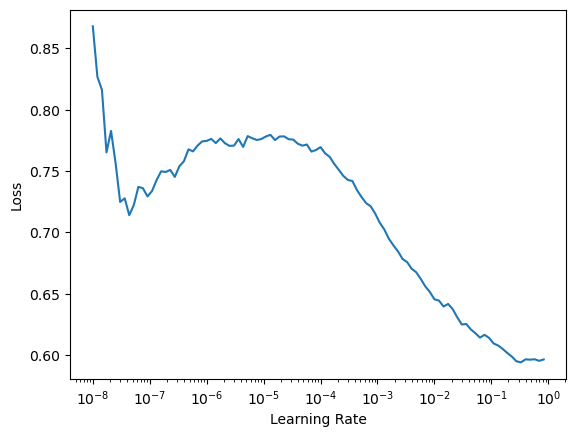

In [24]:
%reset
# learning rate 최적화 (callback을 이용하는 방법)
# 기존 고양이와 멍멍이 이진 학습하는 코드를 예로 들어서 알아보아요!

# 데이터처리
import os   # 폴더 경로 생성하기 위해
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator # 입력데이터 처리
from tensorflow.keras.applications import VGG16   # 성능은 좋지 않지만 알기쉬운 
                                                  # pretrained network(기학습된 네트워크)
from tensorflow.keras.models import Sequential # Model
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.layers import BatchNormalization, Activation
from tensorflow.keras.optimizers import SGD, RMSprop, Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import warnings
warnings.filterwarnings('ignore')

train_dir = './data/cat_dog_small/train'  # 학습용 이미지가 들어가 있는 폴더(상대경로)
validation_dir = './data/cat_dog_small/validation'

# ImageDataGenerator를 생성. 당연히 2개 생성
# train용 1개 - 증식설정이 들어가야 해요!, validation용 1개 - 증식이 들어가면 안되요!
train_datagen = ImageDataGenerator(rescale=1/255.0,
                                   # rotation_range=30,
                                   # width_shift_range=0.1,
                                   # height_shift_range=0.1,
                                   # shear_range=0.2,
                                   # zoom_range=0.2,
                                   # horizontal_flip=True,
                                   # vertical_flip=False,
                                   # fill_mode='nearest'
                                  )

# validation data는 증식을 시키면 안되요!
validation_datagen = ImageDataGenerator(rescale=1/255.0)

# ImageDataGenerator 설정
train_generator = train_datagen.flow_from_directory(
    train_dir,
    classes=['cats', 'dogs'], 
    target_size=(150,150),
    batch_size=20,
    class_mode='binary'
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    classes=['cats', 'dogs'], 
    target_size=(150,150),
    batch_size=20,
    class_mode='binary'
)

# Model 구현
model_base = VGG16(weights='imagenet',
                   include_top=False,
                   input_shape=(150,150,3))

model_base.trainable = False # VGG16안의 convolution layer를 동결(중요!)

model = Sequential()

model.add(model_base)  # 특징추출하는 부분(이미지 1장이 3차원)

model.add(Flatten())   # classifier로 넣어야 해요!(이미지 1장을 1차원)
# hidden layer
model.add(Dense(units=128))
model.add(BatchNormalization())  # 성능향상을 위해 BatchNormalization을 사용해요!
model.add(Activation('relu'))

model.add(Dropout(rate=0.2)) # Activation뒤에 위치시키는게 좋아요!(Dense뒤에 위치)
                     # Convolution layer에서는 Dropout을 일반적으로 사용하지 않아요!
# output layer
model.add(Dense(units=1,
                activation='sigmoid'))

initial_lr = 1e-8
# Model 설정
model.compile(optimizer=Adam(learning_rate=initial_lr),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# learning rate 알아내는 사용자 정의 callback(fast.ai에서 제공)
class LRFinderCallback(tf.keras.callbacks.Callback):
    def __init__(self, min_lr=1e-8, max_lr=10, steps=100):
        self.min_lr = min_lr
        self.max_lr = max_lr
        self.total_steps = steps
        self.history = {'lr': [],
                        'loss': []}
        
    def on_batch_end(self, batch, logs=None):
        lr = self.min_lr * (self.max_lr / self.min_lr) ** (batch / self.total_steps)
        tf.keras.backend.set_value(self.model.optimizer.lr, lr)
        self.history['lr'].append(lr)
        self.history['loss'].append(logs['loss'])

lr_finder = LRFinderCallback(min_lr=1e-8, max_lr=1, steps=100)


# Model 학습
model.fit(train_generator,
          steps_per_epoch=100,
          epochs=1,
          validation_data=validation_generator,
          validation_steps=50,
          callbacks=[lr_finder],
          verbose=1)

plt.plot(lr_finder.history['lr'], lr_finder.history['loss'])
plt.xscale('log')
plt.xlabel('Learning Rate')
plt.ylabel('Loss')
plt.show()


In [ ]:
# 또 다른 방법은 optuna (라이브러리) 사용해서 알아내는 방법
# conda install -c conda-forge optuna 
import optuna
import os   # 폴더 경로 생성하기 위해
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator # 입력데이터 처리
from tensorflow.keras.applications import VGG16   # 성능은 좋지 않지만 알기쉬운 
                                                  # pretrained network(기학습된 네트워크)
from tensorflow.keras.models import Sequential # Model
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.layers import BatchNormalization, Activation
from tensorflow.keras.optimizers import SGD, RMSprop, Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import warnings
warnings.filterwarnings('ignore')

train_dir = './data/cat_dog_small/train'  # 학습용 이미지가 들어가 있는 폴더(상대경로)
validation_dir = './data/cat_dog_small/validation'

# ImageDataGenerator를 생성. 당연히 2개 생성
# train용 1개 - 증식설정이 들어가야 해요!, validation용 1개 - 증식이 들어가면 안되요!
train_datagen = ImageDataGenerator(rescale=1/255.0,
                                   # rotation_range=30,
                                   # width_shift_range=0.1,
                                   # height_shift_range=0.1,
                                   # shear_range=0.2,
                                   # zoom_range=0.2,
                                   # horizontal_flip=True,
                                   # vertical_flip=False,
                                   # fill_mode='nearest'
                                  )

# validation data는 증식을 시키면 안되요!
validation_datagen = ImageDataGenerator(rescale=1/255.0)

# ImageDataGenerator 설정
train_generator = train_datagen.flow_from_directory(
    train_dir,
    classes=['cats', 'dogs'], 
    target_size=(150,150),
    batch_size=20,
    class_mode='binary'
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    classes=['cats', 'dogs'], 
    target_size=(150,150),
    batch_size=20,
    class_mode='binary'
)

# Model 구현
model_base = VGG16(weights='imagenet',
                   include_top=False,
                   input_shape=(150,150,3))

model_base.trainable = False # VGG16안의 convolution layer를 동결(중요!)

model = Sequential()

model.add(model_base)  # 특징추출하는 부분(이미지 1장이 3차원)

model.add(Flatten())   # classifier로 넣어야 해요!(이미지 1장을 1차원)
# hidden layer
model.add(Dense(units=128))
model.add(BatchNormalization())  # 성능향상을 위해 BatchNormalization을 사용해요!
model.add(Activation('relu'))

model.add(Dropout(rate=0.2)) # Activation뒤에 위치시키는게 좋아요!(Dense뒤에 위치)
                     # Convolution layer에서는 Dropout을 일반적으로 사용하지 않아요!
# output layer
model.add(Dense(units=1,
                activation='sigmoid'))

def objective(trial):
    lr = trial.suggest_loguniform('learning_rate',1e-7,1e-1)
    model.compile(optimizer=Adam(learning_rate=lr),
              loss='binary_crossentropy',
              metrics=['accuracy'])
    history = model.fit(train_generator,
          steps_per_epoch=100,
          epochs=10,
          validation_data=validation_generator,
          validation_steps=50,
          verbose=1)
    return history.history['val_accuracy'][-1]

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

print('최적의 parameter : ' + study.best_params['learning_rate'])

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


[I 2025-04-28 15:41:24,124] A new study created in memory with name: no-name-ca1cc0f3-68ef-42d4-9a86-5fc11dfb1be3


Epoch 1/10
100/100 [==============================] - 7s 61ms/step - loss: 0.3815 - accuracy: 0.8380 - val_loss: 0.3487 - val_accuracy: 0.8500
Epoch 2/10
100/100 [==============================] - 6s 59ms/step - loss: 0.1929 - accuracy: 0.9210 - val_loss: 0.3209 - val_accuracy: 0.8770
Epoch 3/10
100/100 [==============================] - 6s 59ms/step - loss: 0.1395 - accuracy: 0.9470 - val_loss: 0.3561 - val_accuracy: 0.8850
Epoch 4/10
100/100 [==============================] - 6s 59ms/step - loss: 0.0839 - accuracy: 0.9685 - val_loss: 0.3385 - val_accuracy: 0.8930
Epoch 5/10
100/100 [==============================] - 6s 61ms/step - loss: 0.0534 - accuracy: 0.9820 - val_loss: 0.4363 - val_accuracy: 0.8900
Epoch 6/10
100/100 [==============================] - 6s 61ms/step - loss: 0.0600 - accuracy: 0.9770 - val_loss: 0.5397 - val_accuracy: 0.8680
Epoch 7/10
100/100 [==============================] - 6s 60ms/step - loss: 0.0582 - accuracy: 0.9750 - val_loss: 0.4300 - val_accuracy: 0.8840

[I 2025-04-28 15:42:26,289] Trial 0 finished with value: 0.8560000061988831 and parameters: {'learning_rate': 0.013476582190380764}. Best is trial 0 with value: 0.8560000061988831.


Epoch 1/10
100/100 [==============================] - 7s 62ms/step - loss: 0.0248 - accuracy: 0.9905 - val_loss: 0.4359 - val_accuracy: 0.8760
Epoch 2/10
100/100 [==============================] - 6s 61ms/step - loss: 0.0438 - accuracy: 0.9860 - val_loss: 0.4185 - val_accuracy: 0.8780
Epoch 3/10
100/100 [==============================] - 6s 62ms/step - loss: 0.0526 - accuracy: 0.9835 - val_loss: 0.4147 - val_accuracy: 0.8810
Epoch 4/10
100/100 [==============================] - 6s 63ms/step - loss: 0.0225 - accuracy: 0.9910 - val_loss: 0.4137 - val_accuracy: 0.8820
Epoch 5/10
100/100 [==============================] - 6s 61ms/step - loss: 0.0221 - accuracy: 0.9910 - val_loss: 0.4133 - val_accuracy: 0.8820
Epoch 6/10
100/100 [==============================] - 6s 61ms/step - loss: 0.0203 - accuracy: 0.9925 - val_loss: 0.4122 - val_accuracy: 0.8840
Epoch 7/10
100/100 [==============================] - 6s 61ms/step - loss: 0.0353 - accuracy: 0.9850 - val_loss: 0.4111 - val_accuracy: 0.8860

[I 2025-04-28 15:43:28,870] Trial 1 finished with value: 0.8870000243186951 and parameters: {'learning_rate': 6.51162188391073e-05}. Best is trial 1 with value: 0.8870000243186951.


Epoch 1/10
100/100 [==============================] - 7s 62ms/step - loss: 0.0372 - accuracy: 0.9895 - val_loss: 0.4386 - val_accuracy: 0.8950
Epoch 2/10
100/100 [==============================] - 6s 61ms/step - loss: 0.0260 - accuracy: 0.9905 - val_loss: 0.4330 - val_accuracy: 0.8890
Epoch 3/10
100/100 [==============================] - 6s 61ms/step - loss: 0.0112 - accuracy: 0.9965 - val_loss: 0.4981 - val_accuracy: 0.8860
Epoch 4/10
100/100 [==============================] - 6s 61ms/step - loss: 0.0075 - accuracy: 0.9975 - val_loss: 0.4898 - val_accuracy: 0.8820
Epoch 5/10
100/100 [==============================] - 6s 60ms/step - loss: 0.0155 - accuracy: 0.9940 - val_loss: 0.4885 - val_accuracy: 0.8840
Epoch 6/10
100/100 [==============================] - 6s 60ms/step - loss: 0.0272 - accuracy: 0.9905 - val_loss: 0.7934 - val_accuracy: 0.8530
Epoch 7/10
 15/100 [===>..........................] - ETA: 3s - loss: 0.0070 - accuracy: 1.0000